# WISDM Dataset 기반 CNN+LSTM 분류

### 결과 분석

CCN3 + LSTM1 Test accuracy: 94.83%

CCN4 + LSTM1 Test accuracy: 94.08%

WISDM 데이터셋을 CNN+LSTM 기반 모델로 학습한 결과 정확도는 일반 CNN3를 구성한 결과랑 비슷하게 나타났다.

WISDM 데이터는 시간적 흐름보다는 짧은 구간에서 나타나는 움직임 패턴이 더 많이 포함되어 있기 때문에 앞에서 실험한 일반 CNN3의 정확도와 큰 차이를 보이지 못해 WISDM에서는 LSTM이 성능 향상에 기여를 못한 것으로 판단된다.

따라서 WISDM 데이터셋에서는 LSTM를 추가한 구조보다 CNN을 깊게 쌓은 CNN4 구조가 더 효과적이라고 볼 수 있다.


In [23]:
# Library imports
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [24]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/WISDM_ar_v1.1_raw.txt"

## 데이터 전처리

1. **raw 데이터 로드**
2. **클린업** : 마지막 NaN 컬럼 제거, 결측 행 dropna, z_axis의 `;` 제거 후 float 변환
3. **Label Encoding** : LabelEncoder로 activity -> 정수
4. **Data Split (user_id 기반)** :
  - user_id ≤ 26
  - 27 ≤ user_id ≤ 31
  - user_id ≥ 32
5. **정규화** : StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation** : sliding window (TIME_STEPS=200, STEP=40)

In [26]:
# raw 데이터 로드
# WISDM raw data는 컬럼명이 없는 형태
# 각 칼럼에 이름 지정
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";") # 세미콜론 이후 내용 무시
print(data.head())


   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


In [27]:
# 클린업
# 문자열 값을 float32 숫자형으로 변환
def convert_to_float(x):
    try:
        return np.float32(x)
    except:
        return np.nan

# 앞에서 raw data를 읽을 때 생긴 불필요한 NaN 컬럼 제거
df = data.drop('NaN', axis=1)
# 결측값 행 제거
df = df.dropna()

# 세미콜론 제거
df["z_axis"] = df["z_axis"].replace(regex=True, to_replace=r';', value=r'')
# x, y, z축 가속도 값을 문자열에서 float32 숫자형으로 변환
df["x_axis"] = df["x_axis"].apply(convert_to_float)
df["y_axis"] = df["y_axis"].apply(convert_to_float)
df["z_axis"] = df["z_axis"].apply(convert_to_float)
df = df.dropna()
df.info()

print("\nActivity counts:")
print(df['activity'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 1098203 entries, 0 to 1098203
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1098203 non-null  int64  
 1   activity   1098203 non-null  object 
 2   timestamp  1098203 non-null  int64  
 3   x_axis     1098203 non-null  float32
 4   y_axis     1098203 non-null  float32
 5   z_axis     1098203 non-null  float32
dtypes: float32(3), int64(2), object(1)
memory usage: 46.1+ MB

Activity counts:
activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


In [28]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print("\nLabel mapping:", dict(enumerate(label_encoder.classes_)))



Label mapping: {0: 'Downstairs', 1: 'Jogging', 2: 'Sitting', 3: 'Standing', 4: 'Upstairs', 5: 'Walking'}


In [29]:
# Data Split (user_id 기반)
# user_id가 26 이하 = train set
df_train = df[df['user_id'] <= 26]
# user_id가 27~31인 = validation set
df_val   = df[(df['user_id'] > 26) & (df['user_id'] < 32)]
# user_id가 32 이상 = test set
df_test  = df[df['user_id'] >= 32]

print(f"\nTrain users: {sorted(df_train['user_id'].unique())}")
print(f"Val   users: {sorted(df_val['user_id'].unique())}")
print(f"Test  users: {sorted(df_test['user_id'].unique())}")



Train users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
Val   users: [np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
Test  users: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]


In [30]:
# 정규화
scaler = StandardScaler()
df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']])
df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']])
df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']])


In [31]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
def create_dataset(x, y, time_steps=200, step=40):
    xs, ys = [], []
    # 전체 데이터를 time_steps 길이만큼 자르고 step 간격으로 이동
    for i in range(0, len(x) - time_steps, step):
        # 현재 window에 해당하는 x/y/z 센서 값 추출
        v = x.iloc[i:i + time_steps].values
        # 현재 window 안에 포함된 activity label 추출
        labels = y.iloc[i:i + time_steps]
        # window 내부에서 가장 많이 등장한 label을 대표 label로 사용
        values, counts = np.unique(labels, return_counts=True)
        mode_label = values[np.argmax(counts)]
        xs.append(v)
        ys.append(mode_label)
    return np.array(xs), np.array(ys)

TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train[['x_axis', 'y_axis', 'z_axis']], df_train['activity_encoded'], TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val[['x_axis', 'y_axis', 'z_axis']],   df_val['activity_encoded'],   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test[['x_axis', 'y_axis', 'z_axis']],  df_test['activity_encoded'],  TIME_STEPS, STEP)

print(f"\nx_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val  : {x_val.shape},  y_val  : {y_val.shape}")
print(f"x_test : {x_test.shape},  y_test : {y_test.shape}")


x_train: (19457, 200, 3), y_train: (19457,)
x_val  : (4100, 200, 3),  y_val  : (4100,)
x_test : (3885, 200, 3),  y_test : (3885,)


In [32]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록 만드는 역할
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.899726615895333), 1: np.float64(0.5175284604745186), 2: np.float64(3.272283888328288), 3: np.float64(4.244546247818499), 4: np.float64(1.4834553217444342), 5: np.float64(0.429912943567988)}


## CNN3+LSTM2 Model


In [33]:
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, MaxPool1D,
    LSTM, Dense, Dropout
)

# CNN+LSTM input shape: (timesteps, features)
input_shape = (x_train.shape[1], x_train.shape[2])
num_classes = len(label_encoder.classes_)

model = Sequential([
    Input(shape=input_shape),             # (200, 3)

    # CNN block 1 — local feature extraction
    Conv1D(64, 5, padding='same'),
    BatchNormalization(),
    ReLU(),

    # CNN block 2
    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(2),                         # (100, 128)

    # CNN block 3
    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),                               # (100, 256)

    # LSTM
    LSTM(64, return_sequences=False),


    # Classifier head
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 200, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,350 (849.02 KB)

 Trainable params: 216,454 (845.52 KB)

 Non-trainable params: 896 (3.50 KB)

None


In [34]:
callbacks = [
    ModelCheckpoint(
        "WISDM_HAR_CNN_LSTM_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8952 - sparse_categorical_accuracy: 0.6459
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.43000, saving model to WISDM_HAR_CNN_LSTM_best.h5



Epoch 1: finished saving model to WISDM_HAR_CNN_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.6392 - sparse_categorical_accuracy: 0.7692 - val_loss: 1.4831 - val_sparse_categorical_accuracy: 0.4300 - learning_rate: 5.0000e-04
Epoch 2/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3731 - sparse_categorical_accuracy: 0.8861
Epoch 2: val_sparse_categorical_accuracy improved from 0.43000 to 0.76902, saving model to WISDM_HAR_CNN_LSTM_best.h5



Epoch 2: finished saving model to WISDM_HAR_CNN_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.2993 - sparse_categorical_accuracy: 0.9185 - val_loss: 0.9533 - val_sparse_categorical_accuracy: 0.7690 - learning_rate: 5.0000e-04
Epoch 3/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2371 - sparse_categorical_accuracy: 0.9421
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.76902
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.2037 - sparse_categorical_accuracy: 0.9499 - val_loss: 1.1894 - val_sparse_categorical_accuracy: 0.7673 - learning_rate: 5.0000e-04
Epoch 4/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1744 - sparse_categorical_accuracy: 0.9565
Epoch 4: val_sparse_categorical_accuracy improved from 0.76902 to 0.78659, saving model to WISDM_HAR_CNN_LSTM_best.h5



Epoch 4: finished saving model to WISDM_HAR_CNN_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.1513 - sparse_categorical_accuracy: 0.9635 - val_loss: 1.2000 - val_sparse_categorical_accuracy: 0.7866 - learning_rate: 5.0000e-04
Epoch 5/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1245 - sparse_categorical_accuracy: 0.9656
Epoch 5: val_sparse_categorical_accuracy improved from 0.78659 to 0.79098, saving model to WISDM_HAR_CNN_LSTM_best.h5



Epoch 5: finished saving model to WISDM_HAR_CNN_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1158 - sparse_categorical_accuracy: 0.9715 - val_loss: 1.2886 - val_sparse_categorical_accuracy: 0.7910 - learning_rate: 5.0000e-04
Epoch 6/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1372 - sparse_categorical_accuracy: 0.9606
Epoch 6: val_sparse_categorical_accuracy did not improve from 0.79098
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1153 - sparse_categorical_accuracy: 0.9701 - val_loss: 0.9520 - val_sparse_categorical_accuracy: 0.7902 - learning_rate: 5.0000e-04
Epoch 7/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1111 - sparse_categorical_accuracy: 0.9746
Epoch 7: val_sparse_categorical_accuracy did not improve from 0.79098
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0982 - sparse_categorical_accuracy: 0.9775 - val_loss: 0.9037 - val_sparse_categorical_accuracy: 0.7868 - learning_rate: 5.0000e-04
Epoch 8/100
303/305 ━━━━━━━━━━━━

...


Epoch 13: finished saving model to WISDM_HAR_CNN_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0405 - sparse_categorical_accuracy: 0.9900 - val_loss: 1.5027 - val_sparse_categorical_accuracy: 0.8027 - learning_rate: 2.5000e-04
Epoch 14/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0269 - sparse_categorical_accuracy: 0.9926
Epoch 14: val_sparse_categorical_accuracy did not improve from 0.80268
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0324 - sparse_categorical_accuracy: 0.9919 - val_loss: 1.6771 - val_sparse_categorical_accuracy: 0.7954 - learning_rate: 2.5000e-04
Epoch 15/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0289 - sparse_categorical_accuracy: 0.9934
Epoch 15: val_sparse_categorical_accuracy improved from 0.80268 to 0.80610, saving model to WISDM_HAR_CNN_LSTM_best.h5



Epoch 15: finished saving model to WISDM_HAR_CNN_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0314 - sparse_categorical_accuracy: 0.9932 - val_loss: 1.6669 - val_sparse_categorical_accuracy: 0.8061 - learning_rate: 2.5000e-04
Epoch 16/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0239 - sparse_categorical_accuracy: 0.9941
Epoch 16: val_sparse_categorical_accuracy improved from 0.80610 to 0.80732, saving model to WISDM_HAR_CNN_LSTM_best.h5



Epoch 16: finished saving model to WISDM_HAR_CNN_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0245 - sparse_categorical_accuracy: 0.9940 - val_loss: 1.6819 - val_sparse_categorical_accuracy: 0.8073 - learning_rate: 2.5000e-04
Epoch 17/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0229 - sparse_categorical_accuracy: 0.9951
Epoch 17: val_sparse_categorical_accuracy improved from 0.80732 to 0.81683, saving model to WISDM_HAR_CNN_LSTM_best.h5



Epoch 17: finished saving model to WISDM_HAR_CNN_LSTM_best.h5

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0249 - sparse_categorical_accuracy: 0.9948 - val_loss: 1.5514 - val_sparse_categorical_accuracy: 0.8168 - learning_rate: 2.5000e-04
Epoch 18/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0172 - sparse_categorical_accuracy: 0.9961
Epoch 18: val_sparse_categorical_accuracy did not improve from 0.81683
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0180 - sparse_categorical_accuracy: 0.9960 - val_loss: 1.6423 - val_sparse_categorical_accuracy: 0.8024 - learning_rate: 1.2500e-04
Epoch 19/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0109 - sparse_categorical_accuracy: 0.9980
Epoch 19: val_sparse_categorical_accuracy did not improve from 0.81683
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0134 - sparse_categorical_accuracy: 0.9971 - val_loss: 1.6614 - val_sparse_catego


Epoch 23: finished saving model to WISDM_HAR_CNN_LSTM_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0110 - sparse_categorical_accuracy: 0.9977 - val_loss: 1.5576 - val_sparse_categorical_accuracy: 0.8220 - learning_rate: 6.2500e-05
Epoch 24/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0120 - sparse_categorical_accuracy: 0.9972
Epoch 24: val_sparse_categorical_accuracy did not improve from 0.82195
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0113 - sparse_categorical_accuracy: 0.9974 - val_loss: 1.7310 - val_sparse_categorical_accuracy: 0.8093 - learning_rate: 6.2500e-05
Epoch 25/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0094 - sparse_categorical_accuracy: 0.9968
Epoch 25: val_sparse_categorical_accuracy did not improve from 0.82195
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0107 - sparse_categorical_accuracy: 0.9969 - val_loss: 1.8064 - val_sparse_categorical_accuracy: 0.8112 - learning_rate: 6.2500e-05
Epoch 26/100
303/305 ━━━━━━

In [35]:
# Model evaluation
model = tf.keras.models.load_model("WISDM_HAR_CNN_LSTM_best.h5")

train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.86%
Training loss: 0.0048
Test accuracy: 94.83%
Test loss: 0.2957


In [36]:
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

  Downstairs       0.78      0.93      0.85       346
     Jogging       0.99      0.95      0.97      1316
     Sitting       1.00      1.00      1.00       300
    Standing       0.95      0.99      0.97       189
    Upstairs       0.90      0.78      0.84       384
     Walking       0.95      0.98      0.97      1350

    accuracy                           0.95      3885
   macro avg       0.93      0.94      0.93      3885
weighted avg       0.95      0.95      0.95      3885



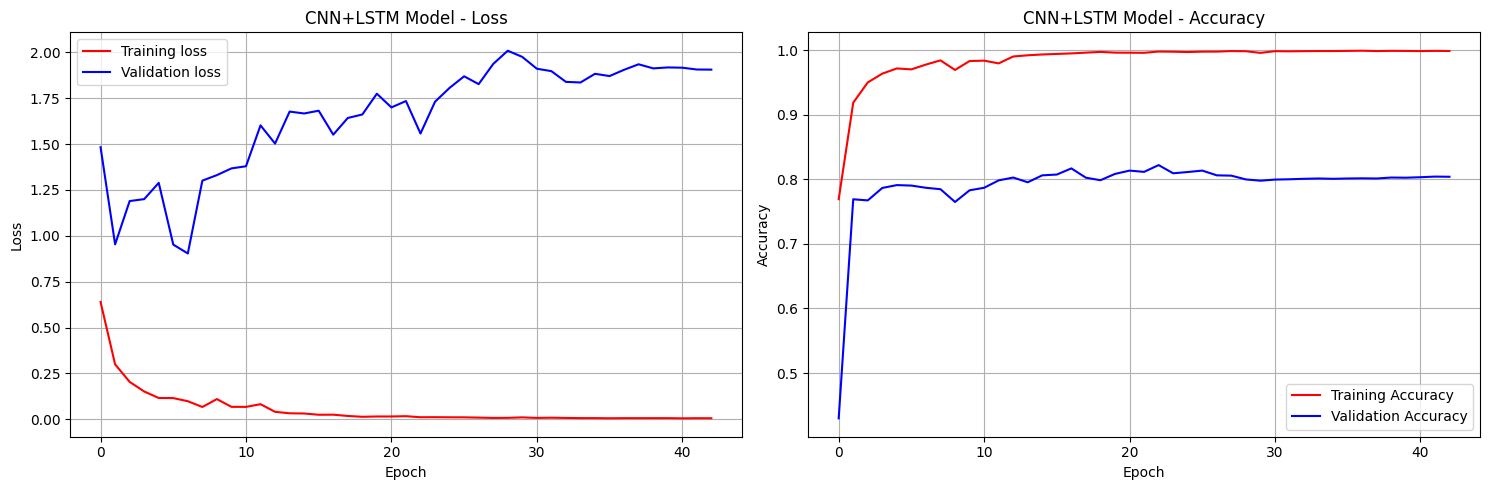

In [37]:
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('CNN+LSTM Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('CNN+LSTM Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

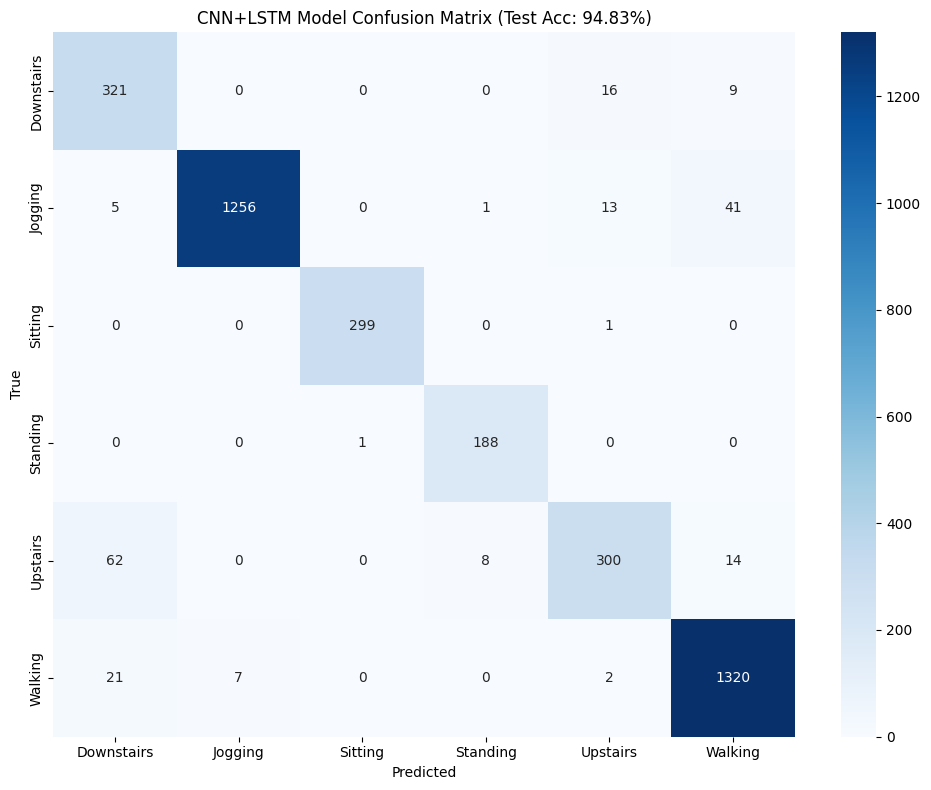

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'CNN+LSTM Model Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## CNN4+LSTM2 Model

In [39]:
input_shape = (x_train.shape[1], x_train.shape[2])
num_classes = len(label_encoder.classes_)

model2 = Sequential([
    Input(shape=input_shape),             # (200, 3)

    # CNN block 1
    Conv1D(64, 5, padding='same'),
    BatchNormalization(),
    ReLU(),

    # CNN block 2
    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(2),                         # (100, 128)

    # CNN block 3
    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    # CNN block 4
    Conv1D(512, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(2),                         # (50, 256)

    # LSTM
    LSTM(64, return_sequences=False),

    # Classifier head
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model2.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model2.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 200, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 100, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 50, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,750 (2.62 MB)

 Trainable params: 685,830 (2.62 MB)

 Non-trainable params: 1,920 (7.50 KB)

None


In [40]:
callbacks2 = [
    ModelCheckpoint(
        "WISDM_HAR_CNN4_LSTM2_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history2 = model2.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks2,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6979 - sparse_categorical_accuracy: 0.7411
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.72244, saving model to WISDM_HAR_CNN4_LSTM2_best.h5



Epoch 1: finished saving model to WISDM_HAR_CNN4_LSTM2_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.4373 - sparse_categorical_accuracy: 0.8533 - val_loss: 0.7837 - val_sparse_categorical_accuracy: 0.7224 - learning_rate: 5.0000e-04
Epoch 2/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1685 - sparse_categorical_accuracy: 0.9564
Epoch 2: val_sparse_categorical_accuracy improved from 0.72244 to 0.74171, saving model to WISDM_HAR_CNN4_LSTM2_best.h5



Epoch 2: finished saving model to WISDM_HAR_CNN4_LSTM2_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.1532 - sparse_categorical_accuracy: 0.9620 - val_loss: 1.1249 - val_sparse_categorical_accuracy: 0.7417 - learning_rate: 5.0000e-04
Epoch 3/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1109 - sparse_categorical_accuracy: 0.9697
Epoch 3: val_sparse_categorical_accuracy improved from 0.74171 to 0.78537, saving model to WISDM_HAR_CNN4_LSTM2_best.h5



Epoch 3: finished saving model to WISDM_HAR_CNN4_LSTM2_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.1049 - sparse_categorical_accuracy: 0.9728 - val_loss: 1.1089 - val_sparse_categorical_accuracy: 0.7854 - learning_rate: 5.0000e-04
Epoch 4/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0803 - sparse_categorical_accuracy: 0.9796
Epoch 4: val_sparse_categorical_accuracy did not improve from 0.78537
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0820 - sparse_categorical_accuracy: 0.9799 - val_loss: 1.1125 - val_sparse_categorical_accuracy: 0.7763 - learning_rate: 5.0000e-04
Epoch 5/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0771 - sparse_categorical_accuracy: 0.9820
Epoch 5: val_sparse_categorical_accuracy did not improve from 0.78537
305/305 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0716 - sparse_categorical_accuracy: 0.9829 - val_loss: 1.3168 - val_sparse_categorical_accuracy: 0.7800 - learning_rate: 5.0000e-04
Epoch 6/100
305/305 ━━━━━━━━━━


Epoch 6: finished saving model to WISDM_HAR_CNN4_LSTM2_best.h5

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.1038 - sparse_categorical_accuracy: 0.9743 - val_loss: 1.0139 - val_sparse_categorical_accuracy: 0.7973 - learning_rate: 5.0000e-04
Epoch 7/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0521 - sparse_categorical_accuracy: 0.9874
Epoch 7: val_sparse_categorical_accuracy improved from 0.79732 to 0.80293, saving model to WISDM_HAR_CNN4_LSTM2_best.h5



Epoch 7: finished saving model to WISDM_HAR_CNN4_LSTM2_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0453 - sparse_categorical_accuracy: 0.9885 - val_loss: 1.0888 - val_sparse_categorical_accuracy: 0.8029 - learning_rate: 2.5000e-04
Epoch 8/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0551 - sparse_categorical_accuracy: 0.9846
Epoch 8: val_sparse_categorical_accuracy improved from 0.80293 to 0.84463, saving model to WISDM_HAR_CNN4_LSTM2_best.h5



Epoch 8: finished saving model to WISDM_HAR_CNN4_LSTM2_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0450 - sparse_categorical_accuracy: 0.9881 - val_loss: 0.6365 - val_sparse_categorical_accuracy: 0.8446 - learning_rate: 2.5000e-04
Epoch 9/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0360 - sparse_categorical_accuracy: 0.9919
Epoch 9: val_sparse_categorical_accuracy did not improve from 0.84463
305/305 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0432 - sparse_categorical_accuracy: 0.9899 - val_loss: 1.3698 - val_sparse_categorical_accuracy: 0.7949 - learning_rate: 2.5000e-04
Epoch 10/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0307 - sparse_categorical_accuracy: 0.9931
Epoch 10: val_sparse_categorical_accuracy did not improve from 0.84463
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0311 - sparse_categorical_accuracy: 0.9926 - val_loss: 1.4944 - val_sparse_categorical_accuracy: 0.7922 - learning_rate: 2.5000e-04
Epoch 11/100
305/305 ━━━━━━━

In [41]:
# Model evaluation
model2 = tf.keras.models.load_model("WISDM_HAR_CNN4_LSTM2_best.h5")

train_loss2, train_acc2 = model2.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc2 * 100:.2f}%")
print(f"Training loss: {train_loss2:.4f}")

test_loss2, test_acc2 = model2.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc2 * 100:.2f}%")
print(f"Test loss: {test_loss2:.4f}")

Training accuracy: 99.26%
Training loss: 0.0226
Test accuracy: 94.08%
Test loss: 0.2450


In [42]:
y_pred_proba2 = model2.predict(x_test, verbose=0)
y_pred2 = np.argmax(y_pred_proba2, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

  Downstairs       0.73      0.92      0.82       346
     Jogging       1.00      0.93      0.96      1316
     Sitting       1.00      1.00      1.00       300
    Standing       0.98      1.00      0.99       189
    Upstairs       0.85      0.80      0.82       384
     Walking       0.96      0.98      0.97      1350

    accuracy                           0.94      3885
   macro avg       0.92      0.94      0.93      3885
weighted avg       0.95      0.94      0.94      3885



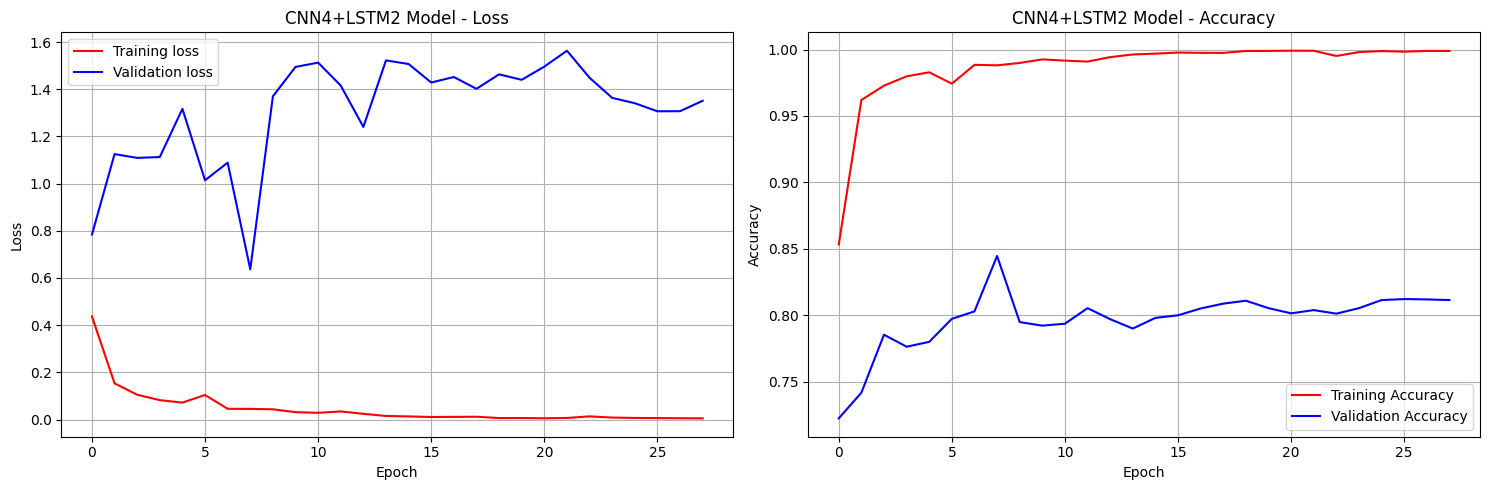

In [43]:
train_loss_h = history2.history['loss']
train_accuracy_h = history2.history['sparse_categorical_accuracy']
val_loss_h = history2.history['val_loss']
val_accuracy_h = history2.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_h, 'r', label='Training loss')
plt.plot(val_loss_h, 'b', label='Validation loss')
plt.title('CNN4+LSTM2 Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy_h, 'r', label='Training Accuracy')
plt.plot(val_accuracy_h, 'b', label='Validation Accuracy')
plt.title('CNN4+LSTM2 Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

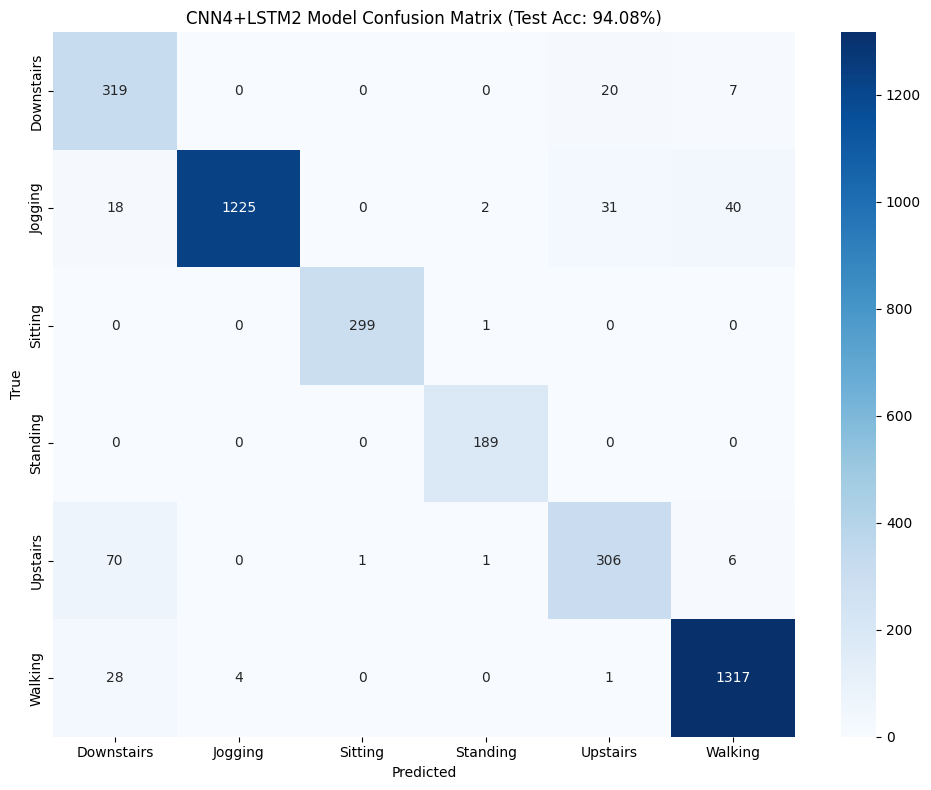

In [44]:
cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'CNN4+LSTM2 Model Confusion Matrix (Test Acc: {test_acc2 * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()